In [174]:
# Core
import os
import pandas as pd
import copy
import numpy as np
import pybedtools

# Graphs
import matplotlib.pyplot as plt
import seaborn as sns
# Statistics
from scipy.stats import fisher_exact
from statsmodels.stats.multitest import multipletests
from scipy.stats import mannwhitneyu
from itertools import combinations
from scipy.stats import binomtest
from adjustText import adjust_text
from sklearn.metrics import precision_recall_curve
from scipy.stats import spearmanr
from scipy.stats import pearsonr
from scipy.stats import ks_2samp


from scipy.stats import ks_2samp # Kolmogorov–Smirnov (KS)
from scipy.stats import linregress
from scipy.stats import gaussian_kde


In [175]:
os.chdir('/home/labs/davidgo/nadavmi/backup')

#import importlib
#importlib.reload(const)

import const #to reload use import(importlib) and then importlib.reload(const)
from const import MPRA_data_paths
from const import pos_active_ctrl_color,neg_active_ctrl_color,highlight_color,custom_cmap
from const import set_equal_plot_limits
from const import plot_color_pallete
from const import custom_cmap_bolder
from const import FONT_SIZE_small
from const import save_fig
const.set_plot_style()

os.chdir('/home/labs/davidgo/Collaboration')

# Load archaic data

In [176]:
# Load archaic MPRA results
archaic_MPRA_output= pd.read_csv(f'ArchaicDerivedMPRA/all_AH_mpra_v3.tsv', 
                     sep='\t',
                     header=0)
archaic_MPRA_output = archaic_MPRA_output[['seq_id','logFC_osteo','logFC_npc',
                           'fdr.mad_adjusted_archaic_osteo','fdr.mad_adjusted_modern_osteo','fdr.comparative_osteo',
                           'fdr.mad_adjusted_archaic_npc','fdr.mad_adjusted_modern_npc','fdr.comparative_npc' ]]

# Add fields
archaic_MPRA_output['active_osteoblasts'] = (archaic_MPRA_output['fdr.mad_adjusted_archaic_osteo'] < 0.05)|(archaic_MPRA_output['fdr.mad_adjusted_modern_osteo'] < 0.05)
archaic_MPRA_output['diff_active_osteoblasts'] = archaic_MPRA_output['fdr.comparative_osteo'] < 0.05

archaic_MPRA_output['active_npc'] = (archaic_MPRA_output['fdr.mad_adjusted_modern_npc'] < 0.05)|(archaic_MPRA_output['fdr.mad_adjusted_archaic_npc'] < 0.05)
archaic_MPRA_output['diff_active_npc'] = archaic_MPRA_output['fdr.comparative_npc'] < 0.05

In [177]:
# Load FIMO and PBM results
archaic_osteo_PBM = pd.read_csv(f'ArchaicDerivedMPRA/TF_analysis/results/arhcaic_osteo_PBM.tsv', sep='\t')
archaic_osteo_PBM['motif_id_clean'] = archaic_osteo_PBM['motif_id_clean'].str.upper()

archaic_osteo_FIMO = pd.read_csv(f'ArchaicDerivedMPRA/TF_analysis/results/arhcaic_osteo_FIMO.tsv', sep='\t')
archaic_osteo_FIMO['motif_id_clean'] = archaic_osteo_FIMO['motif_id_clean'].str.upper()

archaic_npc_PBM = pd.read_csv(f'ArchaicDerivedMPRA/TF_analysis/results/arhcaic_npc_PBM.tsv', sep='\t')
archaic_npc_PBM['motif_id_clean'] = archaic_npc_PBM['motif_id_clean'].str.upper()

archaic_npc_FIMO = pd.read_csv(f'ArchaicDerivedMPRA/TF_analysis/results/arhcaic_npc_FIMO.tsv', sep='\t')
archaic_npc_FIMO['motif_id_clean'] = archaic_npc_FIMO['motif_id_clean'].str.upper()

archaic_osteo = pd.concat([archaic_osteo_PBM, archaic_osteo_FIMO], axis = 0)
archaic_npc = pd.concat([archaic_npc_PBM, archaic_npc_FIMO], axis = 0)

In [178]:
merged_archaic_df = pd.merge(archaic_osteo, archaic_MPRA_output, on='seq_id', how='outer')

PBM_arhciac_osteo_merged_df = pd.merge(archaic_osteo_PBM, archaic_MPRA_output, on='seq_id', how='outer')
FIMO_arhciac_osteo_merged_df = pd.merge(archaic_osteo_FIMO, archaic_MPRA_output, on='seq_id', how='outer')
PBM_arhciac_npc_merged_df = pd.merge(archaic_npc_PBM, archaic_MPRA_output, on='seq_id', how='outer')
FIMO_arhciac_npc_merged_df = pd.merge(archaic_npc_FIMO, archaic_MPRA_output, on='seq_id', how='outer')

# Load modern data

In [179]:
# Load modern results
modern_MPRA_output= pd.read_csv(f'ArchaicDerivedMPRA/TF_analysis/intermediate_files/modern_MPRA_processed.tsv', 
                     sep='\t',
                     header=0)


In [180]:
# Load FIMO and PBM results
modern_osteo_PBM = pd.read_csv(f'ArchaicDerivedMPRA/TF_analysis/results/modern_osteo_PBM.tsv', sep='\t')
modern_osteo_PBM['motif_id_clean'] = modern_osteo_PBM['motif_id_clean'].str.upper()

modern_osteo_FIMO = pd.read_csv(f'ArchaicDerivedMPRA/TF_analysis/results/modern_osteo_FIMO.tsv', sep='\t')
modern_osteo_FIMO['motif_id_clean'] = modern_osteo_FIMO['motif_id_clean'].str.upper()

modern_npc_PBM = pd.read_csv(f'ArchaicDerivedMPRA/TF_analysis/results/modern_npc_PBM.tsv', sep='\t')
modern_npc_PBM['motif_id_clean'] = modern_npc_PBM['motif_id_clean'].str.upper()

modern_npc_FIMO = pd.read_csv(f'ArchaicDerivedMPRA/TF_analysis/results/modern_npc_FIMO.tsv', sep='\t')
modern_npc_FIMO['motif_id_clean'] = modern_npc_FIMO['motif_id_clean'].str.upper()

modern_osteo = pd.concat([modern_osteo_PBM, modern_osteo_FIMO], axis = 0)
modern_npc = pd.concat([modern_npc_PBM, modern_npc_FIMO], axis = 0)

In [181]:
merged_modern_df = pd.merge(modern_osteo, modern_MPRA_output, on='seq_id', how='outer')

PBM_modern_osteo_merged_df = pd.merge(modern_osteo_PBM, modern_MPRA_output, on='seq_id', how='outer')
FIMO_modern_osteo_merged_df = pd.merge(modern_osteo_FIMO, modern_MPRA_output, on='seq_id', how='outer')
PBM_modern_npc_merged_df = pd.merge(modern_npc_PBM, modern_MPRA_output, on='seq_id', how='outer')
FIMO_modern_npc_merged_df = pd.merge(modern_npc_FIMO, modern_MPRA_output, on='seq_id', how='outer')

In [182]:
PBM_all_osteo_merged_df = pd.concat(
    [PBM_modern_osteo_merged_df.assign(population="modern"), 
     PBM_arhciac_osteo_merged_df.assign(population="archaic")],
    axis=0,
    ignore_index=True
)

FIMO_all_osteo_merged_df = pd.concat(
    [FIMO_modern_osteo_merged_df.assign(population="modern"), 
     FIMO_arhciac_osteo_merged_df.assign(population="archaic")],
    axis=0,
    ignore_index=True
)

PBM_all_npc_merged_df = pd.concat(
    [PBM_modern_npc_merged_df.assign(population="modern"), 
     PBM_arhciac_npc_merged_df.assign(population="archaic")],
    axis=0,
    ignore_index=True
)

FIMO_all_npc_merged_df = pd.concat(
    [FIMO_modern_npc_merged_df.assign(population="modern"), 
     FIMO_arhciac_npc_merged_df.assign(population="archaic")],
    axis=0,
    ignore_index=True
)

In [183]:
# get motif lists
PBM_all_osteo_motifs = PBM_all_osteo_merged_df['motif_id_clean'].dropna().unique().tolist()
FIMO_all_osteo_motifs = FIMO_all_osteo_merged_df['motif_id_clean'].dropna().unique().tolist()
PBM_all_npc_motifs = PBM_all_npc_merged_df['motif_id_clean'].dropna().unique().tolist()
FIMO_all_npc_motifs = FIMO_all_npc_merged_df['motif_id_clean'].dropna().unique().tolist()

In [185]:
def keep_most_extreme_diff_binding(df):
    temp = df.copy()
    temp = temp.dropna(subset=["diff_binding_zscore"])
    temp["_abs_z"] = temp["diff_binding_zscore"].abs()
    temp = temp.sort_values(["seq_id", "_abs_z"], ascending=[True, False])
    temp = temp.drop_duplicates(subset="seq_id", keep="first")
    return temp.drop(columns="_abs_z").reset_index(drop=True)

def check_most_extreme_diff_binding(original_df, filtered_df):
    # 1) Check uniqueness of seq_id
    unique_ok = not filtered_df["seq_id"].duplicated().any()

    # 2) Expected absolute max per seq_id from original df
    expected = (
        original_df.assign(abs_z=original_df["diff_binding_zscore"].abs())
        .groupby("seq_id", as_index=False)["abs_z"]
        .max()
        .rename(columns={"abs_z": "expected_abs_z"})
    )

    # 3) Observed absolute z-score in filtered df
    observed = (
        filtered_df.assign(observed_abs_z=filtered_df["diff_binding_zscore"].abs())
        [["seq_id", "diff_binding_zscore", "observed_abs_z"]]
    )

    # 4) Compare
    check_df = expected.merge(observed, on="seq_id", how="outer")
    check_df["matches"] = check_df["expected_abs_z"] == check_df["observed_abs_z"]

    all_ok = unique_ok and check_df["matches"].all() and (len(filtered_df) == original_df["seq_id"].nunique())

    print(f"Unique seq_id check: {unique_ok}")
    print(f"Row count check: {len(filtered_df) == original_df['seq_id'].nunique()}")
    print(f"Extreme-value check: {check_df['matches'].all()}")
    print(f"Overall: {all_ok}")

    return check_df

## Fisher's exact - Bind/ Not Bind // Diff active oligos archaic / Diff active oligos modern

In [186]:
def run_tf_fisher_test(relevant_df, relevant_tfs, diff_active_col,min_binding_threshold):
    results = []

    for tf in relevant_tfs:
        bind_df = relevant_df[relevant_df["motif_id_clean"] == tf]
        not_bind_df = relevant_df[relevant_df["motif_id_clean"] != tf]

        a = bind_df.loc[
            (bind_df[diff_active_col] == 1) & (bind_df["population"] == "archaic"),
            "seq_id"
        ].nunique()

        b = bind_df.loc[
            (bind_df[diff_active_col] == 1) & (bind_df["population"] == "modern"),
            "seq_id"
        ].nunique()

        c = not_bind_df.loc[
            (not_bind_df[diff_active_col] == 1) & (not_bind_df["population"] == "archaic"),
            "seq_id"
        ].nunique()

        d = not_bind_df.loc[
            (not_bind_df[diff_active_col] == 1) & (not_bind_df["population"] == "modern"),
            "seq_id"
        ].nunique()

        table = [[a, b], [c, d]]
        oddsratio, pvalue = fisher_exact(table)

        results.append({
            "TF": tf,
            "a_bind_tf_and_diff_active_archaic": a,
            "b_bind_tf_and_diff_active_modern": b,
            "c_not_bind_tf_and_diff_active_archaic": c,
            "d_not_bind_tf_and_diff_active_modern": d,
            "odds_ratio": oddsratio,
            "pvalue": pvalue
        })

    fisher_df = pd.DataFrame(results)

    sufficient_binding = (
        fisher_df["a_bind_tf_and_diff_active_archaic"] +
        fisher_df["b_bind_tf_and_diff_active_modern"]
    ) >= min_binding_threshold

    fdr_values = np.full(len(fisher_df), np.nan)
    if sufficient_binding.any():
        fdr_values[sufficient_binding] = multipletests(
            fisher_df.loc[sufficient_binding, "pvalue"].values,
            method="fdr_bh"
        )[1]

    fisher_df["pval_fdr"] = fdr_values
    fisher_df = fisher_df.sort_values("pval_fdr").reset_index(drop=True)

    return fisher_df

### FIMO NPCs

In [187]:
fisher_params = {
    "relevant_df": FIMO_all_npc_merged_df.copy(),
    "relevant_tfs": FIMO_all_npc_motifs,
    "diff_active_col": "diff_active_npc",
    "min_binding_threshold": 10
}

fisher_npcs_FIMO_df = run_tf_fisher_test(**fisher_params)
fisher_npcs_FIMO_df

,TF,a_bind_tf_and_diff_active_archaic,b_bind_tf_and_diff_active_modern,c_not_bind_tf_and_diff_active_archaic,d_not_bind_tf_and_diff_active_modern,odds_ratio,pvalue,pval_fdr
0,PLAG1,3,11,233,153,0.179087,0.004810,0.144310
1,RREB1,3,9,234,153,0.217949,0.017405,0.261075
2,ZNF320,6,10,233,153,0.393991,0.074932,0.449591
3,ZNF454,3,8,234,153,0.245192,0.056313,0.449591
4,ZIC5,4,8,234,153,0.326923,0.074701,0.449591
...,...,...,...,...,...,...,...,...
357,CEBPB,0,0,234,153,NaN,1.000000,NaN
358,ZBTB33,0,0,234,153,NaN,1.000000,NaN
359,E2F1,1,1,234,153,0.653846,1.000000,NaN
360,E2F4,0,0,234,153,NaN,1.000000,NaN


### PBM NPCs

In [188]:
fisher_params = {
    "relevant_df": PBM_all_npc_merged_df.copy(),
    "relevant_tfs": PBM_all_npc_motifs,
    "diff_active_col": "diff_active_npc",
    "min_binding_threshold": 10
}

fisher_npcs_PBM_df = run_tf_fisher_test(**fisher_params)
fisher_npcs_PBM_df

,TF,a_bind_tf_and_diff_active_archaic,b_bind_tf_and_diff_active_modern,c_not_bind_tf_and_diff_active_archaic,d_not_bind_tf_and_diff_active_modern,odds_ratio,pvalue,pval_fdr
0,BCL11B,31,25,233,153,0.814249,0.470785,1.0
1,BCL11A,32,30,234,152,0.692877,0.210079,1.0
2,HES5,23,14,234,153,1.074176,1.000000,1.0
3,MITF,22,19,234,153,0.757085,0.406971,1.0
4,MAX,34,20,234,153,1.111538,0.767843,1.0
...,...,...,...,...,...,...,...,...
137,USF1,2,1,234,153,1.307692,1.000000,NaN
138,HESX1,0,0,234,153,NaN,1.000000,NaN
139,CRAMP1L,0,1,234,153,0.000000,0.396907,NaN
140,E4F1,0,0,234,153,NaN,1.000000,NaN


### Osteo FIMO

In [189]:
fisher_params = {
    "relevant_df":FIMO_all_osteo_merged_df.copy(),
    "relevant_tfs": FIMO_all_osteo_motifs,
    "diff_active_col": "diff_active_osteoblasts",
    "min_binding_threshold": 10
}

fisher_osteoblasts_FIMO_df = run_tf_fisher_test(**fisher_params)
fisher_osteoblasts_FIMO_df

,TF,a_bind_tf_and_diff_active_archaic,b_bind_tf_and_diff_active_modern,c_not_bind_tf_and_diff_active_archaic,d_not_bind_tf_and_diff_active_modern,odds_ratio,pvalue,pval_fdr
0,PLAG1,10,13,611,243,0.305930,0.008470,0.334551
1,ZBTB7A,4,8,614,243,0.197883,0.007016,0.334551
2,ZNF707,10,10,611,240,0.392799,0.044059,0.435087
3,ZNF281,17,15,614,243,0.448534,0.029073,0.435087
4,ZBTB18,11,0,612,243,inf,0.040295,0.435087
...,...,...,...,...,...,...,...,...
316,HOXA4,2,0,614,243,inf,1.000000,NaN
317,CEBPB,1,1,614,242,0.394137,0.486459,NaN
318,ZBTB33,1,0,614,243,inf,1.000000,NaN
319,E2F1,1,0,614,243,inf,1.000000,NaN


### Osteo PBM

In [190]:
fisher_params = {
    "relevant_df":PBM_all_osteo_merged_df.copy(),
    "relevant_tfs": PBM_all_osteo_motifs,
    "diff_active_col": "diff_active_osteoblasts",
    "min_binding_threshold": 10
}

fisher_osteoblasts_PBM_df = run_tf_fisher_test(**fisher_params)
fisher_osteoblasts_PBM_df

,TF,a_bind_tf_and_diff_active_archaic,b_bind_tf_and_diff_active_modern,c_not_bind_tf_and_diff_active_archaic,d_not_bind_tf_and_diff_active_modern,odds_ratio,pvalue,pval_fdr
0,MITF,103,43,611,243,0.952651,0.842965,1.0
1,MAX,111,30,612,243,1.469118,0.083570,1.0
2,BHLHE41,82,26,614,243,1.248183,0.425306,1.0
3,ARNTL,62,15,614,243,1.635831,0.110268,1.0
4,TCFL5,59,17,613,243,1.375780,0.288168,1.0
...,...,...,...,...,...,...,...,...
118,E2F4,5,2,614,243,0.989414,1.000000,NaN
119,NPAS2,6,0,614,243,inf,0.192712,NaN
120,USF1,4,4,614,243,0.395765,0.234724,NaN
121,CRAMP1L,6,2,614,243,1.187296,1.000000,NaN


# diff active up vs down

In [191]:
def run_tf_fisher_up_down_by_population(relevant_df, relevant_tfs, diff_active_col, logFC_col,min_binding_threshold):
    results = []

    for tf in relevant_tfs:
        bind_df = relevant_df[
            (relevant_df["motif_id_clean"] == tf) &
            (relevant_df[diff_active_col] == 1)
        ].copy()

        a = bind_df.loc[
            (bind_df["population"] == "archaic") & (bind_df[logFC_col] > 0),
            "seq_id"
        ].nunique()

        b = bind_df.loc[
            (bind_df["population"] == "archaic") & (bind_df[logFC_col] < 0),
            "seq_id"
        ].nunique()

        c = bind_df.loc[
            (bind_df["population"] == "modern") & (bind_df[logFC_col] > 0),
            "seq_id"
        ].nunique()

        d = bind_df.loc[
            (bind_df["population"] == "modern") & (bind_df[logFC_col] < 0),
            "seq_id"
        ].nunique()

        table = [[a, b], [c, d]]
        oddsratio, pvalue = fisher_exact(table)

        results.append({
            "TF": tf,
            "a_archaic_up": a,
            "b_archaic_down": b,
            "c_modern_up": c,
            "d_modern_down": d,
            "odds_ratio": oddsratio,
            "pvalue": pvalue
        })

    fisher_df = pd.DataFrame(results)

    sufficient_binding = (
        fisher_df["a_archaic_up"] +
        fisher_df["b_archaic_down"] +
        fisher_df["c_modern_up"] +
        fisher_df["d_modern_down"]
    ) >= min_binding_threshold

    fdr_values = np.full(len(fisher_df), np.nan)
    if sufficient_binding.any():
        fdr_values[sufficient_binding] = multipletests(
            fisher_df.loc[sufficient_binding, "pvalue"].values,
            method="fdr_bh"
        )[1]

    fisher_df["pval_fdr"] = fdr_values
    fisher_df = fisher_df.sort_values("pval_fdr").reset_index(drop=True)

    return fisher_df

## NPCs FIMO

In [192]:
fisher_params = {
    "relevant_df": FIMO_all_npc_merged_df.copy(),
    "relevant_tfs": FIMO_all_npc_motifs,
    "diff_active_col": "diff_active_npc",
    "logFC_col": "logFC_npc",
    "min_binding_threshold": 20
}
fisher_up_down_df_FIMO_NPCs = run_tf_fisher_up_down_by_population(**fisher_params)
fisher_up_down_df_FIMO_NPCs

,TF,a_archaic_up,b_archaic_down,c_modern_up,d_modern_down,odds_ratio,pvalue,pval_fdr
0,ZNF281,5,7,3,11,2.619048,0.400915,0.89742
1,CTCF,8,5,4,4,1.600000,0.673065,0.89742
2,PATZ1,5,5,4,8,2.000000,0.665635,0.89742
3,KLF16,3,7,3,8,1.142857,1.000000,1.00000
4,ZKSCAN3,1,1,1,0,0.000000,1.000000,NaN
...,...,...,...,...,...,...,...,...
357,CEBPB,0,0,0,0,NaN,1.000000,NaN
358,ZBTB33,0,0,0,0,NaN,1.000000,NaN
359,E2F1,1,0,0,1,inf,1.000000,NaN
360,E2F4,0,0,0,0,NaN,1.000000,NaN


## NPCs PBM

In [193]:
fisher_params = {
    "relevant_df": PBM_all_npc_merged_df.copy(),
    "relevant_tfs": PBM_all_npc_motifs,
    "diff_active_col": "diff_active_npc",
    "logFC_col": "logFC_npc",
    "min_binding_threshold": 20
}
fisher_up_down_df_PBM_NPCs = run_tf_fisher_up_down_by_population(**fisher_params)
fisher_up_down_df_PBM_NPCs

,TF,a_archaic_up,b_archaic_down,c_modern_up,d_modern_down,odds_ratio,pvalue,pval_fdr
0,ARID5B,24,16,3,15,7.500000,0.003795,0.240972
1,HMG20B,18,14,3,15,6.428571,0.008068,0.240972
2,ARID5A,17,14,2,13,7.892857,0.010381,0.240972
3,FOXJ2,20,9,4,11,6.111111,0.011208,0.240972
4,ARID3A,27,17,5,14,4.447059,0.014128,0.242993
...,...,...,...,...,...,...,...,...
137,USF1,1,1,0,1,inf,1.000000,NaN
138,HESX1,0,0,0,0,NaN,1.000000,NaN
139,CRAMP1L,0,0,1,0,NaN,1.000000,NaN
140,E4F1,0,0,0,0,NaN,1.000000,NaN


## Osteo FIMO

In [194]:
fisher_params = {
    "relevant_df": FIMO_all_osteo_merged_df.copy(),
    "relevant_tfs": FIMO_all_osteo_motifs,
    "diff_active_col": "diff_active_osteoblasts",
    "logFC_col": "logFC_osteo",
    "min_binding_threshold": 20
}
fisher_up_down_df_FIMO_Osteo = run_tf_fisher_up_down_by_population(**fisher_params)
fisher_up_down_df_FIMO_Osteo

,TF,a_archaic_up,b_archaic_down,c_modern_up,d_modern_down,odds_ratio,pvalue,pval_fdr
0,CTCF,11,9,1,6,7.333333,0.091379,0.930892
1,PLAG1,6,4,3,10,5.000000,0.102302,0.930892
2,ZNF701,12,5,3,6,4.800000,0.103432,0.930892
3,ZNF281,4,13,5,10,0.615385,0.698860,1.000000
4,ZNF320,9,11,4,11,2.250000,0.312016,1.000000
...,...,...,...,...,...,...,...,...
316,HOXA4,1,1,0,0,NaN,1.000000,NaN
317,CEBPB,1,0,1,0,NaN,1.000000,NaN
318,ZBTB33,1,0,0,0,NaN,1.000000,NaN
319,E2F1,1,0,0,0,NaN,1.000000,NaN


In [195]:
fisher_params = {
    "relevant_df": PBM_all_osteo_merged_df.copy(),
    "relevant_tfs": PBM_all_osteo_motifs,
    "diff_active_col": "diff_active_osteoblasts",
    "logFC_col": "logFC_osteo",
    "min_binding_threshold": 20
}
fisher_up_down_df_PBM_Osteo = run_tf_fisher_up_down_by_population(**fisher_params)
fisher_up_down_df_PBM_Osteo


,TF,a_archaic_up,b_archaic_down,c_modern_up,d_modern_down,odds_ratio,pvalue,pval_fdr
0,IRF2,33,27,2,20,12.222222,0.000141,0.015456
1,AHCTF1,48,43,10,32,3.572093,0.002424,0.066665
2,ELF4,28,18,3,15,7.777778,0.001957,0.066665
3,IRF7,14,5,1,9,25.200000,0.001699,0.066665
4,SETBP1,48,42,9,28,3.555556,0.003224,0.070918
...,...,...,...,...,...,...,...,...
118,MBD1,5,4,3,1,0.416667,1.000000,NaN
119,NPAS2,4,2,0,0,NaN,1.000000,NaN
120,USF1,1,3,0,4,inf,1.000000,NaN
121,CRAMP1L,5,1,1,1,5.000000,0.464286,NaN


## Osteoblasts - Distribution of logFC in archaic vs modern

In [196]:
relevant_df = FIMO_all_npc_merged_df.copy()
relevant_tfs = FIMO_all_npc_motifs
logFC_col = 'logFC_npc'

results = []

for tf in relevant_tfs:
    bind_mask = (relevant_df["motif_id_clean"] == tf)
    bind_df = relevant_df.loc[bind_mask]
    
    # Separate by population
    bind_archaic = bind_df[bind_df['population'] == 'archaic']
    bind_modern = bind_df[bind_df['population'] == 'modern']

    # helper: run U-test on a column, return stats (or NaNs if insufficient)
    def utest(col, x_data, y_data):
        x = x_data[col].dropna().astype(float).values
        y = y_data[col].dropna().astype(float).values

        # Need at least 2 values per group to be meaningful
        if (len(x) < 2) or (len(y) < 2):
            return np.nan, np.nan, len(x), len(y), np.nan, np.nan

        # two-sided by default; method='auto' picks exact/asymptotic as appropriate
        U, p = mannwhitneyu(x, y, alternative="two-sided", method="auto")

        # nice to also report medians (effect direction)
        return U, p, len(x), len(y), np.median(x), np.median(y)

    Uo, po, nbo, nmo, med_bo, med_mo = utest(logFC_col, bind_archaic, bind_modern)

    results.append({
        "TF": tf,

        # osteo
        "n_bind_archaic": nbo,
        "n_bind_modern": nmo,
        "median_bind_archaic_logFC": med_bo,
        "median_bind_modern_logFC": med_mo,
        "U": Uo,
        "pvalue": po,
    })

utest_df = pd.DataFrame(results)

# Only calculate FDR on TFs with sufficient binding events
min_binding_threshold = 10
sufficient_binding = (
    utest_df['n_bind_archaic'] + utest_df['n_bind_modern'] >= min_binding_threshold
)

# initialize column
utest_df['pval_fdr'] = np.nan

# run BH only on valid pvalues among sufficient rows
mask = sufficient_binding & utest_df['pvalue'].notna()
if mask.any():
    pvals = utest_df.loc[mask, 'pvalue'].to_numpy()
    fdrs = multipletests(pvals, method='fdr_bh')[1]
    utest_df.loc[mask, 'pval_fdr'] = fdrs



# direction / effect summary (difference in medians: archaic - modern)
utest_df["delta_median"] = utest_df["median_bind_archaic_logFC"] - utest_df["median_bind_modern_logFC"]

# sort placing smallest osteo FDR first (NaNs last)
#utest_df = utest_df.sort_values("pval_fdr", na_position="last").reset_index(drop=True)

utest_df

,TF,n_bind_archaic,n_bind_modern,median_bind_archaic_logFC,median_bind_modern_logFC,U,pvalue,pval_fdr,delta_median
0,ZKSCAN3,17,58,0.023403,-0.001022,491.0,0.984856,1.000000,0.024424
1,SPIB,40,176,0.008772,-0.011197,3974.0,0.203722,0.860742,0.019969
2,ZNF281,80,205,0.002626,-0.010294,8718.0,0.407816,0.938850,0.012920
3,CTCF,83,246,0.009310,-0.002052,10413.0,0.785948,0.941931,0.011362
4,ZNF684,32,119,0.004326,-0.007620,1845.0,0.789959,0.941931,0.011946
...,...,...,...,...,...,...,...,...,...
357,CEBPB,4,12,0.074959,-0.006823,30.0,0.520879,0.938850,0.081781
358,ZBTB33,3,8,0.162130,-0.035110,21.0,0.084848,0.686501,0.197241
359,E2F1,2,11,-0.237328,-0.039529,10.0,0.923077,0.985743,-0.197799
360,E2F4,3,6,-0.005030,0.022260,8.0,0.904762,NaN,-0.027290


In [197]:
PBM_all_osteo_merged_df

,seq_id,diff_binding_score,diff_binding_zscore,diff_binding_pval,diff_binding_fdr,Mus_musculus,motif_id_clean,Archaic_allele,Modern_allele,mutation,...,diff_active_npc,population,variant_pos,seq_start,seq_end,ref,alt,number_of_variants,motif_association_method,cell_type_used_for_motif_filtering
0,libA_seq100031_[chrX:6904954-6905153],NaN,NaN,NaN,NaN,False,NaN,G,A,A->G,...,False,modern,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,libA_seq100037_[chr6:167526194-167526393],4.959513,4.201501,0.000013,0.000507,False,MITF,T,C,C->T,...,False,modern,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,libA_seq100037_[chr6:167526194-167526393],5.288933,4.149673,0.000017,0.000541,False,MAX,T,C,C->T,...,False,modern,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,libA_seq100037_[chr6:167526194-167526393],3.103116,3.984726,0.000034,0.000749,False,BHLHE41,T,C,C->T,...,False,modern,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,libA_seq100037_[chr6:167526194-167526393],1.617984,3.926432,0.000043,0.000860,False,ARNTL,T,C,C->T,...,False,modern,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
747754,seq9999,0.837920,-0.622042,0.266957,0.408263,True,FOXO3,NaN,NaN,NaN,...,False,archaic,18668495.0,18668361.0,18668630.0,A,C,1.0,PBM,osteoblasts
747755,seq9999,0.820654,-0.547583,0.291989,0.427648,True,DLX1,NaN,NaN,NaN,...,False,archaic,18668495.0,18668361.0,18668630.0,A,C,1.0,PBM,osteoblasts
747756,seq9999,1.068983,0.444012,0.328517,0.453756,True,ARID5A,NaN,NaN,NaN,...,False,archaic,18668495.0,18668361.0,18668630.0,A,C,1.0,PBM,osteoblasts
747757,seq9999,1.059297,0.265519,0.395305,0.497973,True,DLX5,NaN,NaN,NaN,...,False,archaic,18668495.0,18668361.0,18668630.0,A,C,1.0,PBM,osteoblasts


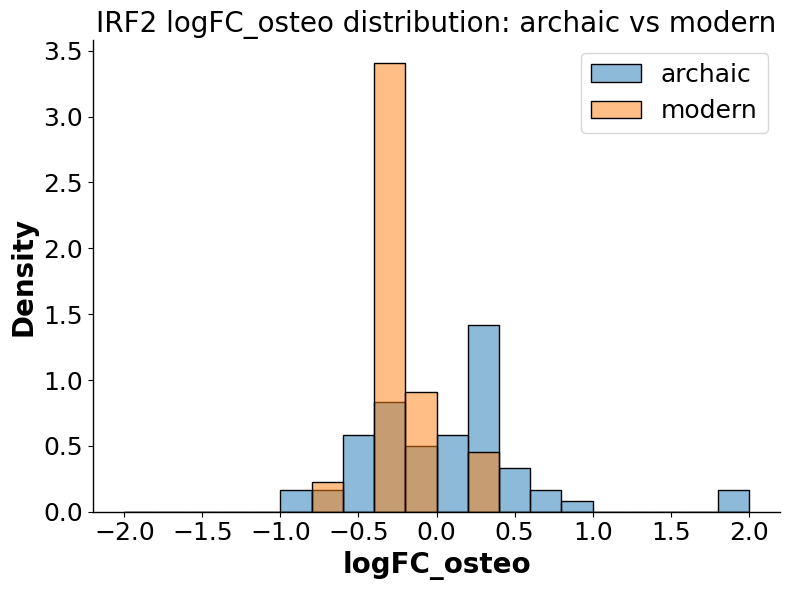

In [228]:
TF = 'IRF2'
logFC_col = 'logFC_osteo'

relevant_df = PBM_all_osteo_merged_df[
    PBM_all_osteo_merged_df['diff_active_osteoblasts'] == 1
]

tf_df = relevant_df[relevant_df['motif_id_clean'] == TF]

arch = tf_df.loc[tf_df['population'] == 'archaic', logFC_col].dropna()
mod  = tf_df.loc[tf_df['population'] == 'modern',  logFC_col].dropna()

# shared bins from -2 to 2
bins = np.linspace(-2, 2, 21)   # 20 equal-width bins

plt.figure(figsize=(8, 6))
sns.histplot(
    arch,
    bins=bins,
    color='tab:blue',
    label='archaic',
    stat='density',
    alpha=0.5,
    kde=False
)
sns.histplot(
    mod,
    bins=bins,
    color='tab:orange',
    label='modern',
    stat='density',
    alpha=0.5,
    kde=False
)

#plt.xlim(-3, 3)
plt.xlabel(logFC_col)
plt.ylabel('Density')
plt.title(f'{TF} {logFC_col} distribution: archaic vs modern')
plt.legend()
plt.tight_layout()

save_fig(plt, 'IRF2_logFC_osteo_distrbution_archaic_vs_modern', 'ArchaicDerivedMPRA/TF_analysis/figures/archaic_vs_modern/')
plt.show()

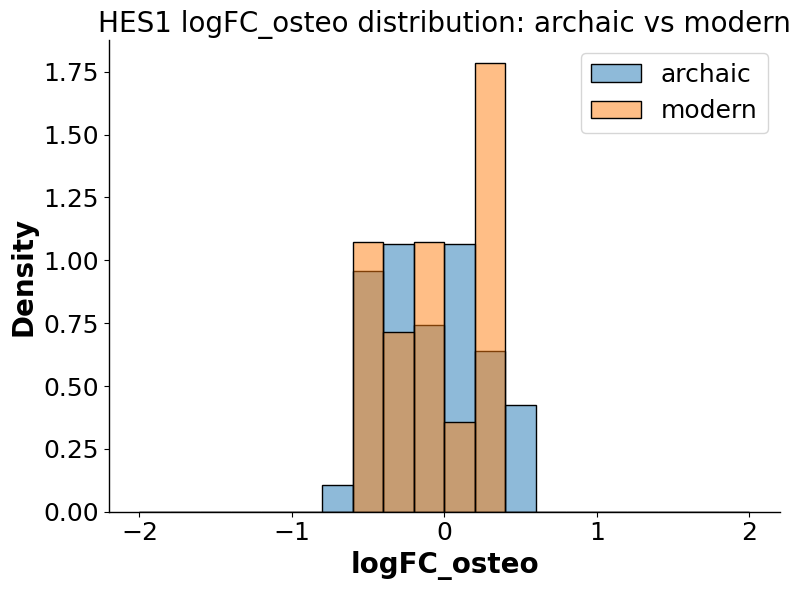

In [199]:
TF = 'HES1'
logFC_col = 'logFC_osteo'

relevant_df = PBM_all_osteo_merged_df[
    PBM_all_osteo_merged_df['diff_active_osteoblasts'] == 1
]

tf_df = relevant_df[relevant_df['motif_id_clean'] == TF]

arch = tf_df.loc[tf_df['population'] == 'archaic', logFC_col].dropna()
mod  = tf_df.loc[tf_df['population'] == 'modern',  logFC_col].dropna()

# shared bins from -2 to 2
bins = np.linspace(-2, 2, 21)   # 20 equal-width bins

plt.figure(figsize=(8, 6))
sns.histplot(
    arch,
    bins=bins,
    color='tab:blue',
    label='archaic',
    stat='density',
    alpha=0.5,
    kde=False
)
sns.histplot(
    mod,
    bins=bins,
    color='tab:orange',
    label='modern',
    stat='density',
    alpha=0.5,
    kde=False
)

#plt.xlim(-3, 3)
plt.xlabel(logFC_col)
plt.ylabel('Density')
plt.title(f'{TF} {logFC_col} distribution: archaic vs modern')
plt.legend()
plt.tight_layout()

save_fig(plt, 'HES1_logFC_osteo_distrbution_archaic_vs_modern', 'ArchaicDerivedMPRA/TF_analysis/figures/archaic_vs_modern/')
plt.show()

# Comparison diff binding TFs in diff active oligos vs active oligos

In [213]:
print(archaic_MPRA_output['diff_active_npc'].sum()+modern_MPRA_output['diff_active_npc'].sum())
print(archaic_MPRA_output['diff_active_osteoblasts'].sum()+modern_MPRA_output['diff_active_osteoblasts'].sum())

388
858


In [139]:
def keep_most_extreme_diff_binding(df):
    temp = df.copy()
    temp = temp.dropna(subset=["diff_binding_zscore"])
    temp["_abs_z"] = temp["diff_binding_zscore"].abs()
    temp = temp.sort_values(["seq_id", "_abs_z"], ascending=[True, False])
    temp = temp.drop_duplicates(subset="seq_id", keep="first")
    return temp.drop(columns="_abs_z").reset_index(drop=True)

def check_most_extreme_diff_binding(original_df, filtered_df):
    # 1) Check uniqueness of seq_id
    unique_ok = not filtered_df["seq_id"].duplicated().any()

    # 2) Expected absolute max per seq_id from original df
    expected = (
        original_df.assign(abs_z=original_df["diff_binding_zscore"].abs())
        .groupby("seq_id", as_index=False)["abs_z"]
        .max()
        .rename(columns={"abs_z": "expected_abs_z"})
    )

    # 3) Observed absolute z-score in filtered df
    observed = (
        filtered_df.assign(observed_abs_z=filtered_df["diff_binding_zscore"].abs())
        [["seq_id", "diff_binding_zscore", "observed_abs_z"]]
    )

    # 4) Compare
    check_df = expected.merge(observed, on="seq_id", how="outer")
    check_df["matches"] = check_df["expected_abs_z"] == check_df["observed_abs_z"]

    all_ok = unique_ok and check_df["matches"].all() and (len(filtered_df) == original_df["seq_id"].nunique())

    print(f"Unique seq_id check: {unique_ok}")
    print(f"Row count check: {len(filtered_df) == original_df['seq_id'].nunique()}")
    print(f"Extreme-value check: {check_df['matches'].all()}")
    print(f"Overall: {all_ok}")

    return check_df

def plot_abs_diff_binding_ecdf_by_diff_activity(
    filtered_df,
    active_col="active_in_cell_type",
    diff_active_col="diff_active_in_cell_type",
    zscore_col="diff_binding_zscore",
    ax=None,
):
    """
    Filter to active enhancers/sites only, then plot two ECDFs of the absolute
    diff_binding_zscore:
      - diff active   (diff_active_col == True)
      - not diff active (diff_active_col == False)

    Parameters
    ----------
    filtered_df : pandas.DataFrame
    active_col : str
        Boolean column used to keep only True rows.
    diff_active_col : str
        Boolean column used to split rows into two groups.
    zscore_col : str
        Numeric column to plot in absolute value.
    ax : matplotlib.axes.Axes or None
        Existing axis to plot on. If None, creates a new figure.

    Returns
    -------
    fig, ax, plot_df
        fig : matplotlib Figure
        ax : matplotlib Axes
        plot_df : filtered dataframe used for plotting
    """
    plot_df = filtered_df.copy()

    # keep only active rows
    plot_df = plot_df[plot_df[active_col] == True].copy()

    # remove missing values just in case
    plot_df = plot_df.dropna(subset=[diff_active_col, zscore_col]).copy()

    # absolute z-score
    plot_df["abs_diff_binding_zscore"] = plot_df[zscore_col].abs()

    # split groups
    diff_active_vals = np.sort(
        plot_df.loc[plot_df[diff_active_col] == True, "abs_diff_binding_zscore"].to_numpy()
    )
    not_diff_active_vals = np.sort(
        plot_df.loc[plot_df[diff_active_col] == False, "abs_diff_binding_zscore"].to_numpy()
    )

    if ax is None:
        fig, ax = plt.subplots(figsize=(7, 5))
    else:
        fig = ax.figure

    # ECDF helper
    def ecdf_y(n):
        return np.arange(1, n + 1) / n if n > 0 else np.array([])

    if len(diff_active_vals) > 0:
        ax.step(
            diff_active_vals,
            ecdf_y(len(diff_active_vals)),
            where="post",
            label=f"Diff active (n={len(diff_active_vals)})",
            linewidth=2,
        )

    if len(not_diff_active_vals) > 0:
        ax.step(
            not_diff_active_vals,
            ecdf_y(len(not_diff_active_vals)),
            where="post",
            label=f"Not diff active (n={len(not_diff_active_vals)})",
            linewidth=2,
        )

    ax.set_xlabel("|diff_binding_zscore|")
    ax.set_ylabel("ECDF")
    ax.set_title("ECDF of absolute diff_binding_zscore")
    ax.legend(frameon=False)
    plt.tight_layout()

    return fig, ax, plot_df

## NPCs FIMO

In [160]:
filtered_FIMO_all_npc_merged_df = keep_most_extreme_diff_binding(FIMO_all_npc_merged_df)
check_df = check_most_extreme_diff_binding(FIMO_all_npc_merged_df.dropna(subset=["diff_binding_zscore"], inplace=False), filtered_FIMO_all_npc_merged_df)

filtered_FIMO_all_npc_merged_df.to_csv('ArchaicDerivedMPRA/TF_analysis/for_ryder/ecdfs/filtered_FIMO_all_npc_merged_df.tsv', sep='\t', index=False)

Unique seq_id check: True
Row count check: True
Extreme-value check: True
Overall: True


/home/labs/davidgo/nadavmi/.local/lib/python3.12/site-packages/scipy/stats/_axis_nan_policy.py:573: RuntimeWarning: ks_2samp: Exact calculation unsuccessful. Switching to method=asymp.
  res = hypotest_fun_out(*samples, **kwds)


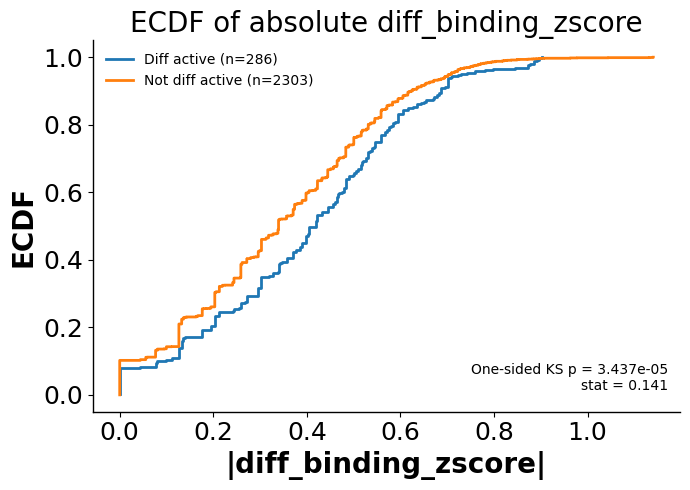

KstestResult(statistic=np.float64(0.14140418851665051), pvalue=np.float64(3.436520415871861e-05), statistic_location=np.float64(0.3737978865222338), statistic_sign=np.int8(-1))


In [202]:
fig, ax, plot_df, ks_result = plot_abs_diff_binding_ecdf_by_diff_activity(filtered_FIMO_all_npc_merged_df,
active_col = "active_npc", diff_active_col = "diff_active_npc",zscore_col = "diff_binding_zscore")
save_fig(plt, 'NPC_FIMO_zscore_correlation_osteobalsts', 'ArchaicDerivedMPRA/TF_analysis/figures/ecdfs')

plt.show()
print(ks_result)



## NPCs PBM

In [172]:
filtered_PBM_all_npc_merged_df = keep_most_extreme_diff_binding(PBM_all_npc_merged_df)
check_df = check_most_extreme_diff_binding(PBM_all_npc_merged_df.dropna(subset=["diff_binding_zscore"], inplace=False), filtered_PBM_all_npc_merged_df)
filtered_PBM_all_npc_merged_df.to_csv('ArchaicDerivedMPRA/TF_analysis/for_ryder/ecdfs/filtered_PBM_all_npc_merged_df.tsv', sep='\t', index=False)


Unique seq_id check: True
Row count check: True
Extreme-value check: True
Overall: True


/home/labs/davidgo/nadavmi/.local/lib/python3.12/site-packages/scipy/stats/_axis_nan_policy.py:573: RuntimeWarning: ks_2samp: Exact calculation unsuccessful. Switching to method=asymp.
  res = hypotest_fun_out(*samples, **kwds)


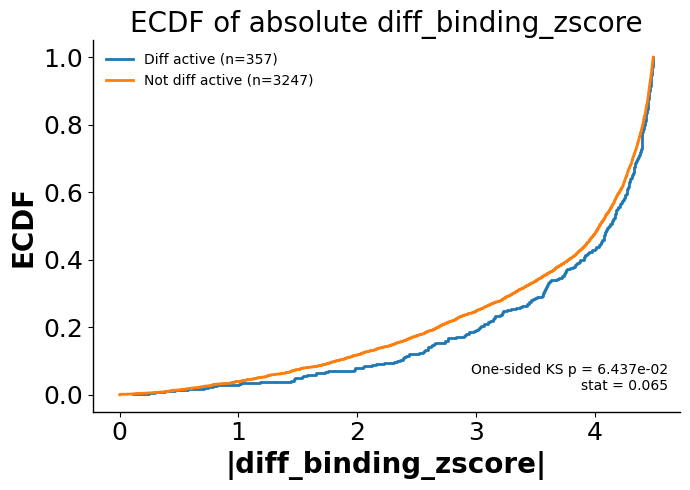

KstestResult(statistic=np.float64(0.06473374690190212), pvalue=np.float64(0.064374245937592), statistic_location=np.float64(2.8982047834543683), statistic_sign=np.int8(-1))


In [203]:
fig, ax, plot_df,ks_result = plot_abs_diff_binding_ecdf_by_diff_activity(filtered_PBM_all_npc_merged_df,
active_col = "active_npc", diff_active_col = "diff_active_npc",zscore_col = "diff_binding_zscore")
save_fig(plt, 'NPC_PBM_zscore_correlation_osteobalsts', 'ArchaicDerivedMPRA/TF_analysis/figures/ecdfs')
plt.show()
print(ks_result)

## Osteo FIMO

In [ ]:
filtered_FIMO_all_osteo_merged_df = keep_most_extreme_diff_binding(FIMO_all_osteo_merged_df)
check_df = check_most_extreme_diff_binding(FIMO_all_osteo_merged_df.dropna(subset=["diff_binding_zscore"], inplace=False), filtered_FIMO_all_osteo_merged_df)
filtered_FIMO_all_osteo_merged_df.to_csv('ArchaicDerivedMPRA/TF_analysis/for_ryder/ecdfs/filtered_FIMO_all_osteo_merged_df.tsv', sep='\t', index=False)



Unique seq_id check: True
Row count check: True
Extreme-value check: True
Overall: True


/home/labs/davidgo/nadavmi/.local/lib/python3.12/site-packages/scipy/stats/_axis_nan_policy.py:573: RuntimeWarning: ks_2samp: Exact calculation unsuccessful. Switching to method=asymp.
  res = hypotest_fun_out(*samples, **kwds)


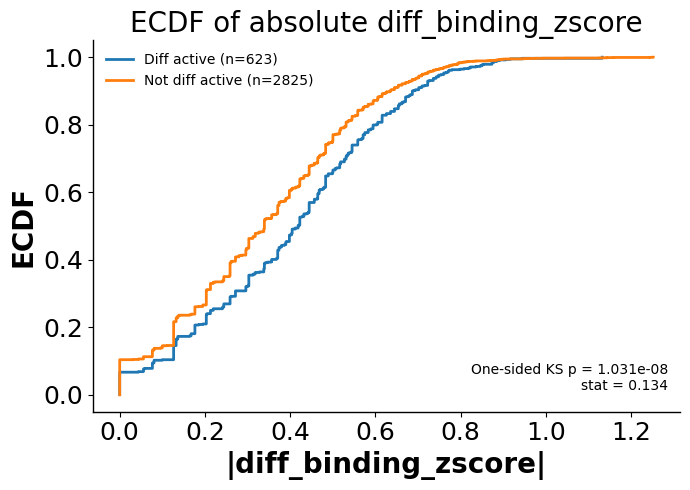

KstestResult(statistic=np.float64(0.13383315103907725), pvalue=np.float64(1.030729590494506e-08), statistic_location=np.float64(0.3766310374586327), statistic_sign=np.int8(-1))


In [222]:
fig, ax, plot_df,ks_result = plot_abs_diff_binding_ecdf_by_diff_activity(filtered_FIMO_all_osteo_merged_df,
active_col = "active_osteoblasts", diff_active_col = "diff_active_osteoblasts",zscore_col = "diff_binding_zscore")
save_fig(plt, 'osteo_FIMO_zscore_correlation_osteobalsts', 'ArchaicDerivedMPRA/TF_analysis/figures/ecdfs')

plt.show()
print(ks_result)

## Osteo PBM

In [171]:
filtered_PBM_all_osteo_merged_df = keep_most_extreme_diff_binding(PBM_all_osteo_merged_df)
check_df = check_most_extreme_diff_binding(PBM_all_osteo_merged_df.dropna(subset=["diff_binding_zscore"], inplace=False), filtered_PBM_all_osteo_merged_df)
filtered_PBM_all_osteo_merged_df.to_csv('ArchaicDerivedMPRA/TF_analysis/for_ryder/ecdfs/filtered_PBM_all_osteo_merged_df.tsv', sep='\t', index=False)



Unique seq_id check: True
Row count check: True
Extreme-value check: True
Overall: True


/home/labs/davidgo/nadavmi/.local/lib/python3.12/site-packages/scipy/stats/_axis_nan_policy.py:573: RuntimeWarning: ks_2samp: Exact calculation unsuccessful. Switching to method=asymp.
  res = hypotest_fun_out(*samples, **kwds)


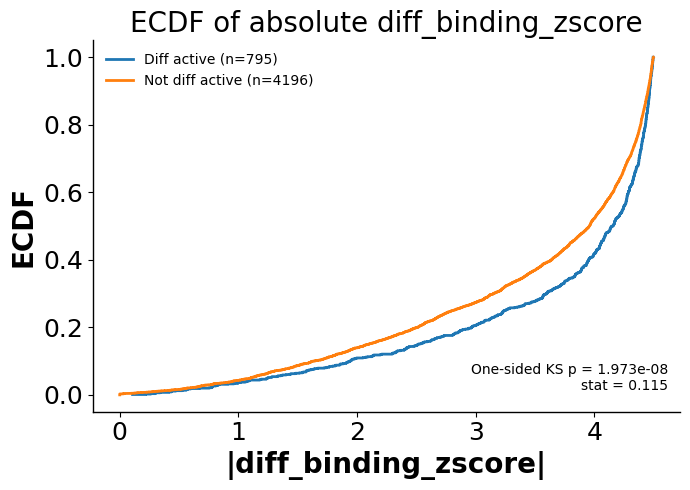

KstestResult(statistic=np.float64(0.11491507335527697), pvalue=np.float64(1.9732065976785258e-08), statistic_location=np.float64(4.263833387378667), statistic_sign=np.int8(-1))


In [223]:
fig, ax, plot_df,ks_result = plot_abs_diff_binding_ecdf_by_diff_activity(filtered_PBM_all_osteo_merged_df,
active_col = "active_osteoblasts", diff_active_col = "diff_active_osteoblasts",zscore_col = "diff_binding_zscore")
save_fig(plt, 'osteo_PBM_zscore_correlation_osteobalsts', 'ArchaicDerivedMPRA/TF_analysis/figures/ecdfs')

plt.show()
print(ks_result)